In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Punto 2A 

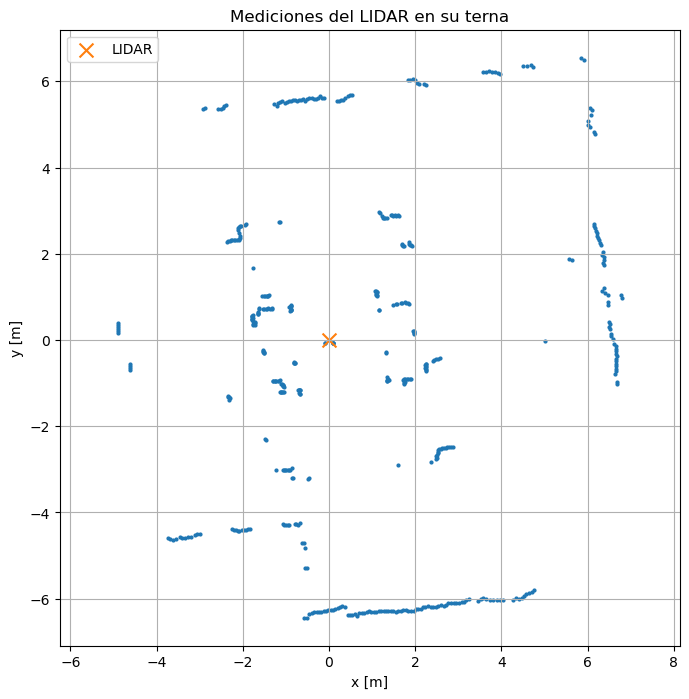

In [ ]:

with open("scan.pkl", "rb") as f:
    scan = pickle.load(f)
    
angle_min = scan["angle_min"]
angle_increment = scan["angle_increment"]
ranges = np.array(scan["ranges"])

angles = angle_min + np.arange(len(ranges)) * angle_increment

# Polar a cartesiana
x = ranges * np.cos(angles)
y = ranges * np.sin(angles)

plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=4)
plt.scatter(0, 0, marker="x", s=100, label="LIDAR")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Mediciones del LIDAR en su terna")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

Punto 2C

Las mediciones se pueden interpretar como una nube de puntos en 2D que representa lo que el lidar detecta alrededor suyo. Cada punto corresponde a una medición de distancia en una cierta dirección, es decir a una superficie que fue alcanzada por uno de los rayos del sensor. Mirando cómo se distribuyen los puntos, se pueden reconocer posibles paredes, bordes u obstáculos cercanos. Cuando aparecen varios puntos alineados, podriamos decir que hay una superficie continua (como por ejemplo una pared). En cambio, grupos más aislados pueden indicar objetos separados. El gráfico muestra una reconstrucción parcial del entorno a partir de los contornos visibles desde la posición del lidar.

Punto 2D

Posición del robot en la terna global:
(-2.5545, -3.7187)


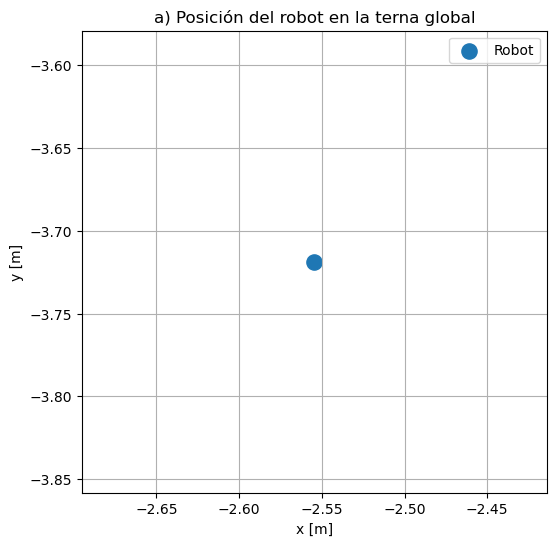


Posición del LIDAR en la terna global:
(-2.5944, -3.7161)


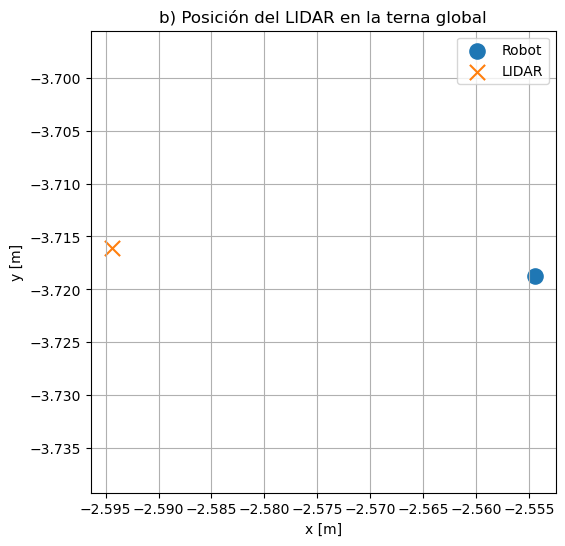

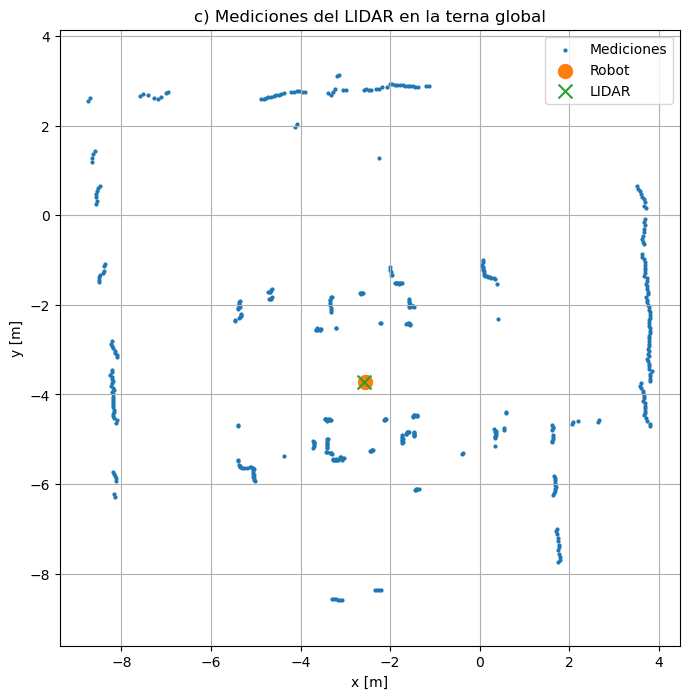

In [ ]:
odom = pd.read_csv("odom.csv")
row = odom.iloc[0]

x_robot = row["pos_x"]
y_robot = row["pos_y"]

qx = row["quat_x"]
qy = row["quat_y"]
qz = row["quat_z"]
qw = row["quat_w"]

theta = np.arctan2(
    2 * (qw * qz + qx * qy),
    1 - 2 * (qy**2 + qz**2)
)

# Transformacion terna local robot a global
T_global_robot = np.array([
    [np.cos(theta), -np.sin(theta), x_robot],
    [np.sin(theta),  np.cos(theta), y_robot],
    [0, 0, 1]
])

# Transformacion terna local lidar a local robot  
T_robot_lidar = np.array([
    [0, -1, -0.04],
    [1,  0,  0.00],
    [0,  0,  1.00]
])

# Transformacion terna local lidar a local robot
T_global_lidar = T_global_robot @ T_robot_lidar

#Posicion del lidar en terna global
lidar_global = T_global_lidar @ np.array([0, 0, 1])
x_lidar_global = lidar_global[0]
y_lidar_global = lidar_global[1]

with open("scan.pkl", "rb") as f:
    scan = pickle.load(f)

angle_min = scan["angle_min"]
angle_increment = scan["angle_increment"]
ranges = np.array(scan["ranges"])

angles = angle_min + np.arange(len(ranges)) * angle_increment

valid = np.isfinite(ranges)
ranges = ranges[valid]
angles = angles[valid]

# Puntos en la terna del lidar
x_lidar_points = ranges * np.cos(angles)
y_lidar_points = ranges * np.sin(angles)

points_lidar = np.vstack([
    x_lidar_points,
    y_lidar_points,
    np.ones_like(x_lidar_points)
])

# Puntos en la terna global
points_global = T_global_lidar @ points_lidar
x_global_points = points_global[0, :]
y_global_points = points_global[1, :]

# a) Posicion del robot en terna global
print("Posición del robot en la terna global:")
print(f"({x_robot:.4f}, {y_robot:.4f})")

plt.figure(figsize=(6, 6))
plt.scatter(x_robot, y_robot, marker="o", s=120, label="Robot")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("a) Posición del robot en la terna global")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# b) Posicion del lidar en terna global
print("\nPosición del LIDAR en la terna global:")
print(f"({x_lidar_global:.4f}, {y_lidar_global:.4f})")

plt.figure(figsize=(6, 6))
plt.scatter(x_robot, y_robot, marker="o", s=120, label="Robot")
plt.scatter(x_lidar_global, y_lidar_global, marker="x", s=120, label="LIDAR")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("b) Posición del LIDAR en la terna global")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

# c) Mediciones del lidar en terna global
plt.figure(figsize=(8, 8))
plt.scatter(x_global_points, y_global_points, s=4, label="Mediciones")
plt.scatter(x_robot, y_robot, marker="o", s=100, label="Robot")
plt.scatter(x_lidar_global, y_lidar_global, marker="x", s=100, label="LIDAR")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("c) Mediciones del LIDAR en la terna global")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()

Punto 3A

In [5]:
def diffdrive(x, y, theta, v_l, v_r, t, l):
    v = (v_r + v_l) / 2
    omega = (v_r - v_l) / l

    if np.isclose(omega, 0):
        x_n = x + v * np.cos(theta) * t
        y_n = y + v * np.sin(theta) * t
        theta_n = theta
    else:
        x_n = x + (v / omega) * (np.sin(theta + omega * t) - np.sin(theta))
        y_n = y - (v / omega) * (np.cos(theta + omega * t) - np.cos(theta))
        theta_n = theta + omega * t

    return x_n, y_n, theta_n

Pose luego de c1:
(-0.0079, 0.5380, 2.3854)

Pose luego de c2:
(-0.0157, 1.0759, 0.7854)

Pose luego de c3:
(0.2671, 1.3588, 0.7854)

Pose luego de c4:
(0.6445, 1.3312, -7.2146)

Pose luego de c5:
(1.1219, 0.6892, -7.2146)

Pose luego de c6:
(1.1219, 0.6892, -8.8146)

Pose luego de c7:
(0.3023, 0.1162, -8.8146)



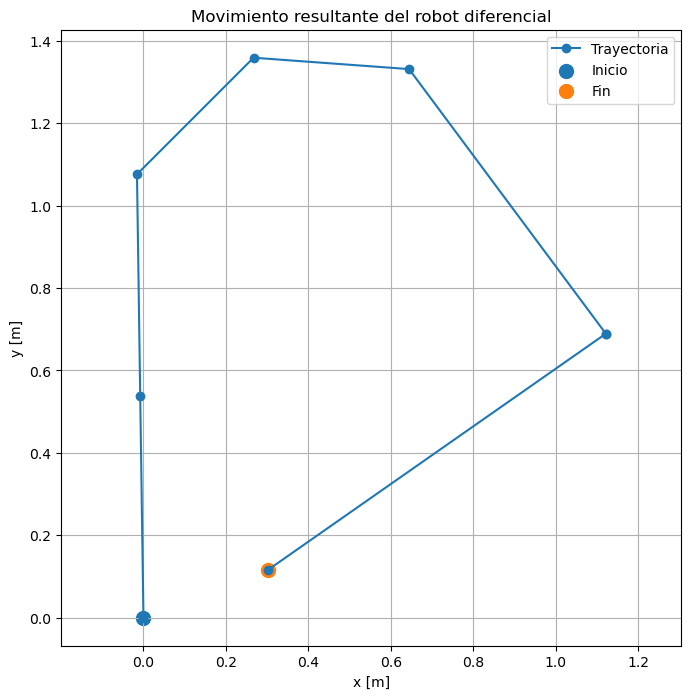

In [ ]:
x = 0.0
y = 0.0
theta = np.pi / 4

l = 0.5

acciones = [
    (0.1, 0.5, 2),
    (0.5, 0.1, 2),
    (0.2, 0.2, 2),
    (1.0, 0.0, 4),
    (0.4, 0.4, 2),
    (0.2, -0.2, 2),
    (0.5, 0.5, 2)
]

xs = [x]
ys = [y]
thetas = [theta]

for i, (v_l, v_r, t) in enumerate(acciones, start=1):
    x, y, theta = diffdrive(x, y, theta, v_l, v_r, t, l)
    xs.append(x)
    ys.append(y)
    thetas.append(theta)

    print(f"Pose luego de c{i}:")
    print(f"({x:.4f}, {y:.4f}, {theta:.4f})")
    print()

plt.figure(figsize=(8, 8))
plt.plot(xs, ys, '-o', label="Trayectoria")
plt.scatter(xs[0], ys[0], s=100, label="Inicio")
plt.scatter(xs[-1], ys[-1], s=100, label="Fin")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Movimiento resultante del robot diferencial")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()